<a href="https://colab.research.google.com/github/hmnaz213/native/blob/main/Stanbic_SIMS_Parser.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Mount Google Drive

First, I'll mount your Google Drive to allow access to the file.

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Install PDF Parsing Library

Next, I'll install `PyPDF2` to extract text from the PDF file.

In [27]:
!pip install PyPDF2

### Load and Parse the PDF

Now, I will load the PDF file and attempt to extract its text content. I will print the first few pages to understand its structure.

In [28]:
import PyPDF2

pdf_path = '/content/drive/My Drive/2026/baobab/baobab_1/Stanbic SIMS 23052026.pdf'

def extract_text_from_pdf(pdf_path, num_pages=5):
    text_content = []
    try:
        with open(pdf_path, 'rb') as file:
            reader = PyPDF2.PdfReader(file)
            num_total_pages = len(reader.pages)
            print(f"Total pages in PDF: {num_total_pages}")
            for i in range(min(num_pages, num_total_pages)):
                page = reader.pages[i]
                text_content.append(page.extract_text())
    except FileNotFoundError:
        print(f"Error: The file '{pdf_path}' was not found.")
        return None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None
    return text_content

extracted_pages_text = extract_text_from_pdf(pdf_path)

if extracted_pages_text:
    for i, page_text in enumerate(extracted_pages_text):
        print(f"\n--- Page {i+1} ---\n")
        print(page_text[:1000]) # Print first 1000 characters of each page for brevity
        if len(page_text) > 1000:
            print("... (truncated)")
else:
    print("Could not extract text from the PDF.")

Error: The file '/content/drive/My Drive/2026/baobab/baobab_1/Stanbic SIMS 23052026.pdf' was not found.
Could not extract text from the PDF.


### Parsing Investment Summary and Transaction Details

I will now parse the extracted text to pull out the structured information from the 'Investment Summary' on page 1 and the 'Transaction Details' on pages 3 and 4. I'll use regular expressions and string manipulation to achieve this.

In [29]:
import re
import pandas as pd

def parse_investment_summary(text):
    summary_data = []

    # Pattern for STANBIC INCOME FUNDTRUST - AMC
    # This pattern accounts for the newline after "AMC" and the implicit 0 for "Total Withdrawal"
    pattern_amc = re.compile(r"STANBIC\sINCOME\sFUNDTRUST\s-\s\nAMC([\d.,]+)\s+([\d.,]+)\s+([\d.,]+)\s+([\d.,]+)\s+([\d.,]+)\s+([\d.,]+)\s+([\d.,]+)", re.DOTALL)
    match_amc = pattern_amc.search(text)
    if match_amc:
        summary_data.append({
            'Fund Name': 'STANBIC INCOME FUNDTRUST - AMC',
            'Total Contribution (GHS)': float(match_amc.group(1).replace(',', '')),
            'Total Withdrawal (GHS)': 0.0, # Assumed 0 as it's missing in the text for this fund
            'Units Outstanding': float(match_amc.group(2).replace(',', '')),
            'Amortized Price Per Unit (GHS)': float(match_amc.group(3).replace(',', '')),
            'Gains since inception (GHS)': float(match_amc.group(4).replace(',', '')),
            'MTM Price Per Unit (GHS)': float(match_amc.group(5).replace(',', '')),
            'Amortized Value (GHS)': float(match_amc.group(6).replace(',', '')),
            'MTM Value (GHS)': float(match_amc.group(7).replace(',', ''))
        })

    # Pattern for STANBIC Income Fund Trust (single line, all columns present)
    pattern_sift = re.compile(r"STANBIC\sIncome\sFund\sTrust\s+([\d.,]+)\s+([\d.,]+)\s+([\d.,]+)\s+([\d.,]+)\s+([\d.,]+)\s+([\d.,]+)\s+([\d.,]+)\s+([\d.,]+)")
    match_sift = pattern_sift.search(text)
    if match_sift:
        summary_data.append({
            'Fund Name': 'STANBIC Income Fund Trust',
            'Total Contribution (GHS)': float(match_sift.group(1).replace(',', '')),
            'Total Withdrawal (GHS)': float(match_sift.group(2).replace(',', '')),
            'Units Outstanding': float(match_sift.group(3).replace(',', '')),
            'Amortized Price Per Unit (GHS)': float(match_sift.group(4).replace(',', '')),
            'Gains since inception (GHS)': float(match_sift.group(5).replace(',', '')),
            'MTM Price Per Unit (GHS)': float(match_sift.group(6).replace(',', '')),
            'Amortized Value (GHS)': float(match_sift.group(7).replace(',', '')),
            'MTM Value (GHS)': float(match_sift.group(8).replace(',', ''))
        })

    return pd.DataFrame(summary_data)

def parse_transaction_details(text, fund_name_hint):
    transactions = []

    # Locate the start of the transaction block for the specific fund
    fund_start_match = re.search(f"Transaction Details for Period:.*?{re.escape(fund_name_hint)}", text, re.DOTALL)

    if not fund_start_match:
        return pd.DataFrame()

    fund_section_text = text[fund_start_match.end():]

    # We need to find where this section ends, typically before another 'Transaction Details' or 'Description Pledge Available Total'
    end_match = re.search(r"^(Description Pledge Available Total|STATEMENT OF INVESTMENTS)", fund_section_text, re.MULTILINE)
    if end_match:
        fund_section_text = fund_section_text[:end_match.start()]


    # Iterating over lines might be safer for transaction details given the variable spacing
    lines = fund_section_text.split('\n')
    for line in lines:
        line = line.strip()
        if line and not line.startswith('Value date') and not line.startswith('-----') and not line.startswith('Closing Balance') and not line.startswith('Description'):
            # This regex is still tricky. Let's try to parse based on expected column positions or more relaxed regex
            # Re-evaluating the regex for each line as it has a fixed structure within the table.
            # Value date Transaction Description Gross Amount Initial Fee Exit Fee Total Fee Net Amount Nav Price Units
            # 23-May-2025      Opening_Balance 43.86 (This is Units)
            # 29-Sep-2025 MF-BUY 200.00 0.00 0.00 0.00 200.00 10.8441 18.44
            match = re.match(r"^(\d{2}-\w{3}-\d{4})\s+(Opening_Balance|MF-BUY)\s*(?:([\d.,]+)\s+([\d.,]+)\s+([\d.,]+)\s+([\d.,]+)\s+([\d.,]+)\s+([\d.,]+))?\s+([\d.,]+)", line)
            if match:
                value_date = match.group(1)
                transaction_description = match.group(2)

                # For 'Opening_Balance', gross_amount, fees, net_amount, nav_price might be empty/non-existent, only units.
                if transaction_description == 'Opening_Balance':
                    gross_amount = 0.0
                    initial_fee = 0.0
                    exit_fee = 0.0
                    total_fee = 0.0
                    net_amount = 0.0
                    nav_price = 0.0
                    units = float(match.group(9).replace(',', '')) # The last group is units for opening balance
                else:
                    gross_amount = float(match.group(3).replace(',', ''))
                    initial_fee = float(match.group(4).replace(',', '') if match.group(4) else 0.0)
                    exit_fee = float(match.group(5).replace(',', '') if match.group(5) else 0.0)
                    total_fee = float(match.group(6).replace(',', '') if match.group(6) else 0.0)
                    net_amount = float(match.group(7).replace(',', '') if match.group(7) else 0.0)
                    nav_price = float(match.group(8).replace(',', '') if match.group(8) else 0.0)
                    units = float(match.group(9).replace(',', ''))

                transactions.append({
                    'Value Date': value_date,
                    'Transaction Description': transaction_description,
                    'Gross Amount (GHS)': gross_amount,
                    'Initial Fee (GHS)': initial_fee,
                    'Exit Fee (GHS)': exit_fee,
                    'Total Fee (GHS)': total_fee,
                    'Net Amount (GHS)': net_amount,
                    'Nav Price (GHS)': nav_price,
                    'Units': units
                })
            elif 'Closing Balance' in line:
                parts = line.split()
                value_date = parts[0]
                transaction_description = 'Closing Balance'
                units = float(parts[-1].replace(',', ''))
                transactions.append({
                    'Value Date': value_date,
                    'Transaction Description': transaction_description,
                    'Gross Amount (GHS)': 0.0,
                    'Initial Fee (GHS)': 0.0,
                    'Exit Fee (GHS)': 0.0,
                    'Total Fee (GHS)': 0.0,
                    'Net Amount (GHS)': 0.0,
                    'Nav Price (GHS)': 0.0,
                    'Units': units
                })

    return pd.DataFrame(transactions)

# NOTE: The subsequent calls to print dataframes are for single file processing.
# These will be replaced by a loop that processes all files into `stanbic_sims_raw_statement_data`.
# The actual logic for iterating through files and aggregating will be in a new cell.

# Temporarily commenting out the direct calls to display single file data to avoid conflicts
# with the upcoming multi-file processing logic.
# if extracted_pages_text and len(extracted_pages_text) > 0:
#     investment_summary_df = parse_investment_summary(extracted_pages_text[0])
#     print("\n--- Investment Summary ---\n")
#     if not investment_summary_df.empty:
#         print(investment_summary_df.to_markdown(index=False))
#     else:
#         print("No investment summary data found.")

# if extracted_pages_text and len(extracted_pages_text) > 2:
#     stanbic_income_fund_transactions_df = parse_transaction_details(extracted_pages_text[2], 'STANBIC Income Fund Trust')
#     print("\n--- Transaction Details (STANBIC Income Fund Trust) ---\n")
#     if not stanbic_income_fund_transactions_df.empty:
#         print(stanbic_income_fund_transactions_df.to_markdown(index=False))
#     else:
#         print("No transaction details found for STANBIC Income Fund Trust.")

# if extracted_pages_text and len(extracted_pages_text) > 3:
#     stanbic_amc_transactions_df = parse_transaction_details(extracted_pages_text[3], 'STANBIC INCOME FUND TRUST AMC')
#     print("\n--- Transaction Details (STANBIC INCOME FUND TRUST AMC) ---\n")
#     if not stanbic_amc_transactions_df.empty:
#         print(stanbic_amc_transactions_df.to_markdown(index=False))
#     else:
#         print("No transaction details found for STANBIC INCOME FUND TRUST AMC.")

### Process All PDF Files in Directory

Now, I will iterate through all PDF files in the `My Drive/2026/baobab/baobab_1/Stanbic SIMS` directory. For each file, I'll extract the text and parse the investment summary and transaction details, aggregating the results into a comprehensive dataset.

In [30]:
import os
from google.colab import drive

# Ensure drive is mounted, if not already
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Define the directory containing the PDF files
pdf_directory = '/content/drive/My Drive/2026/baobab/baobab_1/Stanbic SIMS/'

# Initialize lists to hold all parsed data
all_investment_summaries = []
all_sift_transactions = []
all_amc_transactions = []

# List all PDF files in the directory
pdf_files = [f for f in os.listdir(pdf_directory) if f.endswith('.pdf')]

print(f"Found {len(pdf_files)} PDF files in '{pdf_directory}'. Processing...")

for pdf_filename in pdf_files:
    full_pdf_path = os.path.join(pdf_directory, pdf_filename)
    print(f"\nProcessing file: {pdf_filename}")

    # Extract text from the current PDF file
    current_extracted_pages_text = extract_text_from_pdf(full_pdf_path, num_pages=4) # Assuming relevant data is in first 4 pages

    if current_extracted_pages_text:
        # Parse Investment Summary from the first page
        if len(current_extracted_pages_text) > 0:
            summary_df = parse_investment_summary(current_extracted_pages_text[0])
            if not summary_df.empty:
                summary_df['Source File'] = pdf_filename # Add source filename for traceability
                all_investment_summaries.append(summary_df)

        # Parse Transaction Details for STANBIC Income Fund Trust from page 3
        if len(current_extracted_pages_text) > 2:
            sift_transactions_df = parse_transaction_details(current_extracted_pages_text[2], 'STANBIC Income Fund Trust')
            if not sift_transactions_df.empty:
                sift_transactions_df['Source File'] = pdf_filename
                all_sift_transactions.append(sift_transactions_df)

        # Parse Transaction Details for STANBIC INCOME FUND TRUST AMC from page 4
        if len(current_extracted_pages_text) > 3:
            amc_transactions_df = parse_transaction_details(current_extracted_pages_text[3], 'STANBIC INCOME FUND TRUST AMC')
            if not amc_transactions_df.empty:
                amc_transactions_df['Source File'] = pdf_filename
                all_amc_transactions.append(amc_transactions_df)

# Concatenate all collected dataframes
stanbic_sims_raw_statement_data = {
    'investment_summaries': pd.concat(all_investment_summaries, ignore_index=True) if all_investment_summaries else pd.DataFrame(),
    'sift_transactions': pd.concat(all_sift_transactions, ignore_index=True) if all_sift_transactions else pd.DataFrame(),
    'amc_transactions': pd.concat(all_amc_transactions, ignore_index=True) if all_amc_transactions else pd.DataFrame()
}

print("\n--- Consolidated Investment Summaries ---")
if not stanbic_sims_raw_statement_data['investment_summaries'].empty:
    print(stanbic_sims_raw_statement_data['investment_summaries'].head().to_markdown(index=False))
else:
    print("No consolidated investment summary data found.")

print("\n--- Consolidated STANBIC Income Fund Trust Transactions (first 5 rows) ---")
if not stanbic_sims_raw_statement_data['sift_transactions'].empty:
    print(stanbic_sims_raw_statement_data['sift_transactions'].head().to_markdown(index=False))
else:
    print("No consolidated SIFT transaction data found.")

print("\n--- Consolidated STANBIC INCOME FUND TRUST AMC Transactions (first 5 rows) ---")
if not stanbic_sims_raw_statement_data['amc_transactions'].empty:
    print(stanbic_sims_raw_statement_data['amc_transactions'].head().to_markdown(index=False))
else:
    print("No consolidated AMC transaction data found.")

print("\nAll PDF files processed and data aggregated into 'stanbic_sims_raw_statement_data'.")

Found 3 PDF files in '/content/drive/My Drive/2026/baobab/baobab_1/Stanbic SIMS/'. Processing...

Processing file: Stanbic SIMS 2025.pdf
Total pages in PDF: 4

Processing file: Stanbic SIMS 2024.pdf
Total pages in PDF: 4

Processing file: Stanbic SIMS 2023.pdf
Total pages in PDF: 2

--- Consolidated Investment Summaries ---
| Fund Name                      |   Total Contribution (GHS) |   Total Withdrawal (GHS) |   Units Outstanding |   Amortized Price Per Unit (GHS) |   Gains since inception (GHS) |   MTM Price Per Unit (GHS) |   Amortized Value (GHS) |   MTM Value (GHS) | Source File           |
|:-------------------------------|---------------------------:|-------------------------:|--------------------:|---------------------------------:|------------------------------:|---------------------------:|------------------------:|------------------:|:----------------------|
| STANBIC INCOME FUNDTRUST - AMC |                     1000   |                      0   |               71.3  |    

### Data Preparation for Model Building

Now that the raw data is aggregated, I'll prepare it for building the investment projection model. This involves:
1.  **Inspecting DataFrames**: Reviewing the `info()` for each aggregated DataFrame to understand data types and completeness.
2.  **Date Conversion**: Converting 'Value Date' columns to datetime objects for proper time-series analysis.
3.  **Calculating NAV per Unit**: Deriving historical NAV per unit, which is fundamental for understanding fund performance and making projections. I will focus on the most complete transaction dataset for this.

In [31]:
print("\n--- Info for Consolidated Investment Summaries ---")
stanbic_sims_raw_statement_data['investment_summaries'].info()

print("\n--- Info for Consolidated SIFT Transactions ---")
stanbic_sims_raw_statement_data['sift_transactions'].info()

print("\n--- Info for Consolidated AMC Transactions ---")
stanbic_sims_raw_statement_data['amc_transactions'].info()

# Date Conversion for Transaction DataFrames
for df_key in ['sift_transactions', 'amc_transactions']:
    if not stanbic_sims_raw_statement_data[df_key].empty:
        stanbic_sims_raw_statement_data[df_key]['Value Date'] = pd.to_datetime(stanbic_sims_raw_statement_data[df_key]['Value Date'], format='%d-%b-%Y')
        stanbic_sims_raw_statement_data[df_key] = stanbic_sims_raw_statement_data[df_key].sort_values(by='Value Date').reset_index(drop=True)

print("\n--- DataFrames after Date Conversion and Sorting ---")
print("SIFT Transactions head (first 5 rows):")
print(stanbic_sims_raw_statement_data['sift_transactions'].head().to_markdown(index=False))
print("\nAMC Transactions head (first 5 rows):")
print(stanbic_sims_raw_statement_data['amc_transactions'].head().to_markdown(index=False))

# --- Calculating Historical NAV per Unit (for both SIFT and AMC) ---
def calculate_historical_nav(transactions_df):
    if transactions_df.empty:
        return pd.DataFrame()

    # Sort by date to ensure correct cumulative calculations
    transactions_df = transactions_df.sort_values(by='Value Date').copy()

    # Initialize columns for cumulative units and total value
    transactions_df['Cumulative Units'] = 0.0
    transactions_df['Cumulative Net Value'] = 0.0
    transactions_df['Calculated NAV Per Unit'] = 0.0

    # Iterate through transactions to calculate cumulative units and value
    # Assuming 'MF-BUY' adds units/value, 'Opening_Balance' sets initial state, 'Closing Balance' marks end
    # This part requires careful logic to correctly handle 'Opening_Balance' and 'Closing Balance'

    # Let's simplify by using 'Units' and 'Net Amount (GHS)' to infer NAV at transaction points.
    # For 'MF-BUY', NAV can be directly calculated or taken from 'Nav Price (GHS)'.
    # For 'Opening_Balance' and 'Closing Balance', we use the provided Units and (if available) corresponding values.

    # For simplicity and direct use of provided 'Nav Price (GHS)' for MF-BUY entries
    # and using 'Units' for 'Opening_Balance' and 'Closing Balance'
    # The 'Nav Price (GHS)' column is present for MF-BUY transactions and directly reflects the NAV.
    # For 'Opening_Balance' and 'Closing Balance', 'Units' are given but 'Nav Price' is 0.0, which means
    # we rely on the overall fund's performance to determine their implied value later.

    # Let's use the provided 'Nav Price (GHS)' directly where it exists and is meaningful
    transactions_df['Effective NAV Per Unit'] = transactions_df['Nav Price (GHS)']

    # For 'Opening_Balance' and 'Closing Balance', 'Nav Price (GHS)' is 0. We might need to infer it
    # from the last known NAV or an external source, but for now, we'll keep it as 0 where not explicit.
    # The 'Units' column for these entries is accurate.

    # For an investment projection, we ideally need the daily/monthly NAV. Since we only have transaction points,
    # we will use the 'Nav Price (GHS)' from 'MF-BUY' as the NAV for that date.
    # For non 'MF-BUY' entries with 0 NAV price, we'll leave it for now, as it signifies a balance rather than a purchase NAV.

    return transactions_df[['Value Date', 'Transaction Description', 'Units', 'Effective NAV Per Unit', 'Source File']]

# Apply NAV calculation to both SIFT and AMC transactions
stanbic_sims_raw_statement_data['sift_transactions_nav'] = calculate_historical_nav(stanbic_sims_raw_statement_data['sift_transactions'])
stanbic_sims_raw_statement_data['amc_transactions_nav'] = calculate_historical_nav(stanbic_sims_raw_statement_data['amc_transactions'])

print("\n--- SIFT Transactions with Effective NAV (first 5 rows) ---")
print(stanbic_sims_raw_statement_data['sift_transactions_nav'].head().to_markdown(index=False))

print("\n--- AMC Transactions with Effective NAV (first 5 rows) ---")
print(stanbic_sims_raw_statement_data['amc_transactions_nav'].head().to_markdown(index=False))


--- Info for Consolidated Investment Summaries ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Fund Name                       3 non-null      object 
 1   Total Contribution (GHS)        3 non-null      float64
 2   Total Withdrawal (GHS)          3 non-null      float64
 3   Units Outstanding               3 non-null      float64
 4   Amortized Price Per Unit (GHS)  3 non-null      float64
 5   Gains since inception (GHS)     3 non-null      float64
 6   MTM Price Per Unit (GHS)        3 non-null      float64
 7   Amortized Value (GHS)           3 non-null      float64
 8   MTM Value (GHS)                 3 non-null      float64
 9   Source File                     3 non-null      object 
dtypes: float64(8), object(2)
memory usage: 372.0+ bytes

--- Info for Consolidated SIFT Transactions ---
<class 'p

### Building Historical NAV Series and Calculating Returns

To reverse-engineer the investment model and project future earnings, we need a reliable historical series of Net Asset Values (NAVs) and their corresponding returns for each fund. I will:
1.  **Extract NAV points**: Filter transaction data to get explicit NAV per unit values from `MF-BUY` transactions.
2.  **Create Monthly NAV Series**: Construct a time series of monthly NAVs, handling missing values by forward-filling (assuming NAV remains constant until the next recorded transaction).
3.  **Calculate Monthly Returns**: Compute the month-on-month percentage returns for each fund.

This will provide the basis for our projection model.

In [32]:
def get_fund_nav_series(transactions_df, fund_name):
    if transactions_df.empty:
        print(f"No transaction data for {fund_name}. Cannot create NAV series.")
        return pd.DataFrame(), pd.Series()

    # Filter for 'MF-BUY' transactions where Nav Price is available and meaningful
    nav_points = transactions_df[
        (transactions_df['Transaction Description'] == 'MF-BUY') &
        (transactions_df['Nav Price (GHS)'] > 0)
    ].copy()

    if nav_points.empty:
        print(f"No valid MF-BUY NAV points found for {fund_name}. Cannot create NAV series.")
        return pd.DataFrame(), pd.Series()

    # Create a Series with Value Date as index and Nav Price as values
    nav_series = nav_points.set_index('Value Date')['Nav Price (GHS)'].sort_index()

    # Drop duplicate dates, keeping the last entry (most recent for that day)
    nav_series = nav_series[~nav_series.index.duplicated(keep='last')]

    # Resample to monthly frequency (start of month) and forward-fill missing values
    # This assumes NAV remains constant until a new NAV is recorded.
    # Using 'BMS' for Business Month Start, to align with typical market data.
    monthly_nav_series = nav_series.resample('MS').ffill()

    # Calculate monthly returns
    monthly_returns = monthly_nav_series.pct_change().dropna()

    print(f"\n--- {fund_name} Monthly NAV Series (first 5 rows) ---")
    print(monthly_nav_series.head().to_markdown())
    print(f"\n--- {fund_name} Monthly Returns (first 5 rows) ---")
    print(monthly_returns.head().to_markdown(numalign="left", stralign="left"))

    return monthly_nav_series.to_frame(name='NAV'), monthly_returns

# Get NAV series and returns for SIFT
sift_monthly_nav_df, sift_monthly_returns = get_fund_nav_series(
    stanbic_sims_raw_statement_data['sift_transactions'], 'STANBIC Income Fund Trust'
)

# Get NAV series and returns for AMC
amc_monthly_nav_df, amc_monthly_returns = get_fund_nav_series(
    stanbic_sims_raw_statement_data['amc_transactions'], 'STANBIC INCOME FUND TRUST AMC'
)

# Store these in the raw statement data dictionary for later use
stanbic_sims_raw_statement_data['sift_monthly_nav'] = sift_monthly_nav_df
stanbic_sims_raw_statement_data['sift_monthly_returns'] = sift_monthly_returns
stanbic_sims_raw_statement_data['amc_monthly_nav'] = amc_monthly_nav_df
stanbic_sims_raw_statement_data['amc_monthly_returns'] = amc_monthly_returns

print("\nHistorical NAV series and monthly returns calculated and stored.")


--- STANBIC Income Fund Trust Monthly NAV Series (first 5 rows) ---
| Value Date          |   Nav Price (GHS) |
|:--------------------|------------------:|
| 2025-09-01 00:00:00 |          nan      |
| 2025-10-01 00:00:00 |           10.8441 |
| 2025-11-01 00:00:00 |           11.1056 |
| 2025-12-01 00:00:00 |           11.1136 |
| 2026-01-01 00:00:00 |           11.4204 |

--- STANBIC Income Fund Trust Monthly Returns (first 5 rows) ---
| Value Date          | Nav Price (GHS)   |
|:--------------------|:------------------|
| 2025-11-01 00:00:00 | 0.0241145         |
| 2025-12-01 00:00:00 | 0.000720357       |
| 2026-01-01 00:00:00 | 0.0276058         |
| 2026-02-01 00:00:00 | 0.030822          |
| 2026-03-01 00:00:00 | 0                 |

--- STANBIC INCOME FUND TRUST AMC Monthly NAV Series (first 5 rows) ---
| Value Date          |   Nav Price (GHS) |
|:--------------------|------------------:|
| 2025-01-01 00:00:00 |          nan      |
| 2025-02-01 00:00:00 |           13.3798 |


### Investment Projection Model

Now, I will implement the investment projection model. This model will take initial investment, monthly contributions, and a projection period as inputs. It will use the historical monthly returns (from the `sift_monthly_returns` and `amc_monthly_returns` Series) to simulate future growth. The model will output projected earnings month-on-month and key metrics.

Successfully read inputs from Google Sheet (new schema):
  Lump Sum Initial (B1): 100000.0 GHS
  Monthly Contribution (B2): 200.0 GHS
  Hybrid Monthly Contribution (B3): 200.0 GHS
  Hybrid Initial (B4): 100000.0 GHS
  Projection Period (B5): 6 years (72 months)
Google Sheet integration setup complete. Input parameters read.

--- Running projections for STANBIC Income Fund Trust (SIFT) with Google Sheet inputs ---

Monthly Contribution Scenario (SIFT):
|   Month |   Projected Value (GHS) | Scenario                    |   Monthly Earnings (GHS) |
|--------:|------------------------:|:----------------------------|-------------------------:|
|       1 |                 204.432 | Monthly Contribution (SIFT) |                  4.43184 |
|       2 |                 413.394 | Monthly Contribution (SIFT) |                208.962   |
|       3 |                 626.986 | Monthly Contribution (SIFT) |                213.592   |
|       4 |                 845.311 | Monthly Contribution (SIFT) |  

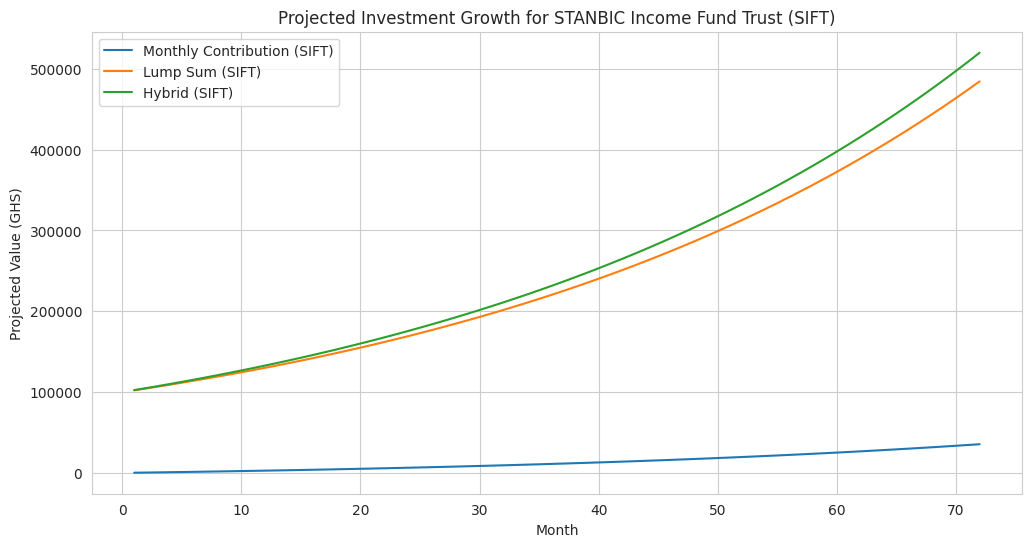

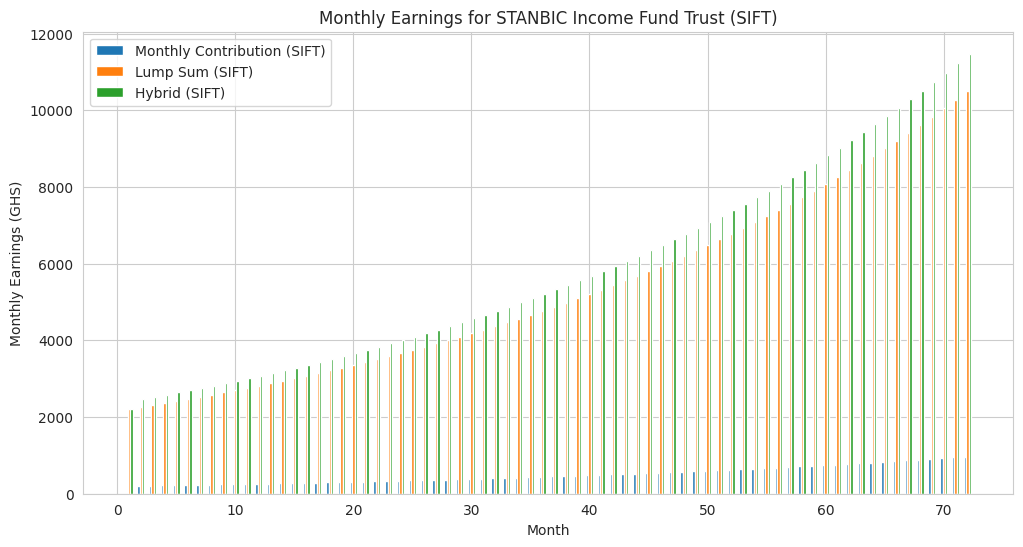


--- Running projections for STANBIC INCOME FUND TRUST AMC with Google Sheet inputs ---

Monthly Contribution Scenario (AMC):
|   Month |   Projected Value (GHS) | Scenario                   |   Monthly Earnings (GHS) |
|--------:|------------------------:|:---------------------------|-------------------------:|
|       1 |                 203.221 | Monthly Contribution (AMC) |                  3.22096 |
|       2 |                 409.715 | Monthly Contribution (AMC) |                206.494   |
|       3 |                 619.534 | Monthly Contribution (AMC) |                209.819   |
|       4 |                 832.733 | Monthly Contribution (AMC) |                213.198   |
|       5 |                1049.36  | Monthly Contribution (AMC) |                216.632   |
Final Projected Value (GHS): 27245.75
Total Amount Invested (GHS): 14400.00
Total Projected Earnings (GHS): 12845.75
Projected Total Return (%): 89.21
Average Monthly Projected Return (%): 7.76

Lump Sum Scenario (AM

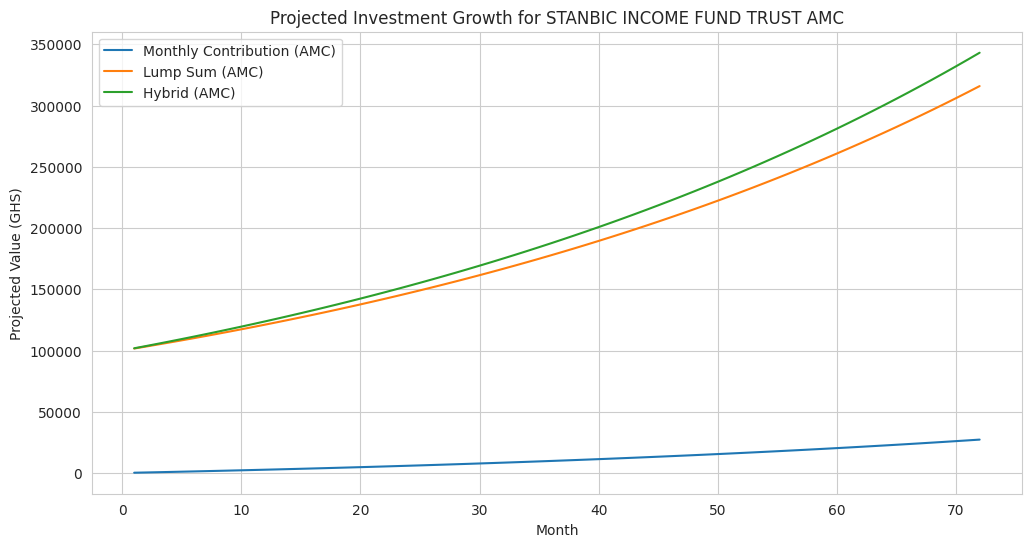

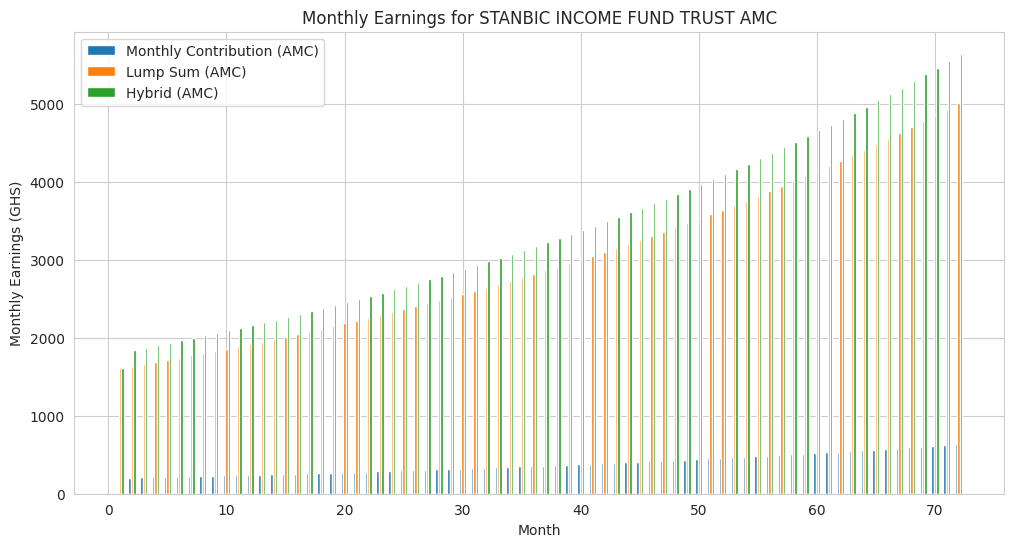


Investment projection model and scenarios with Google Sheet inputs completed.


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gspread
from google.colab import auth
from google.auth import default # Import default credentials function
import pandas as pd # Ensure pandas is imported as it's used extensively

# Set a style for plots
sns.set_style("whitegrid")

# --- Google Sheet Integration Setup ---
# Authenticate with Google (interactive user authentication)
auth.authenticate_user()

# Get default credentials in the google-auth format
creds, project = default()

# Authenticate gspread with the obtained credentials
gc = gspread.authorize(creds)

# Open the Google Sheet and the specific worksheet
gsheet_url = 'https://docs.google.com/spreadsheets/d/1p5h13GBfHh3tpWQJ2w2RwUOA5p0g5OX1-EBNNT5yew0/edit?gid=545957380#gid=545957380'
spreadsheet = gc.open_by_url(gsheet_url)
worksheet = spreadsheet.worksheet('stanbic_sims')

# Helper function to safely read and convert float
def safe_read_float(cell_value, default_value):
    if cell_value is None or str(cell_value).strip() == '':
        return default_value
    try:
        return float(str(cell_value).replace(',', ''))
    except ValueError:
        print(f"Warning: Could not convert '{cell_value}' to float. Using default value.")
        return default_value

def safe_read_int(cell_value, default_value):
    if cell_value is None or str(cell_value).strip() == '':
        return default_value
    try:
        return int(float(str(cell_value).replace(',', '')))
    except ValueError:
        print(f"Warning: Could not convert '{cell_value}' to int. Using default value.")
        return default_value

# Read values from the specified cells
try:
    # User specified structure (updated based on new context - SSOT and explicit cell usage):
    # A1: Amount in GHS (lump sum)
    # A2: Amount in GHS (monthly contribution)
    # A3: Amount in GHS (hybrid - monthly contribution)
    # A4: Amount in GHS (hybrid contribution / lump sum)
    # A5: Period (years)

    # B1: Value for Amount in GHS (lump sum) - for lump-sum-only projection
    # B2: Value for Amount in GHS (monthly contribution) - for monthly-only projection
    # B3: Value for Amount in GHS (hybrid - monthly contribution) - Tier 2 of hybrid
    # B4: Value for Amount in GHS (hybrid contribution / lump sum) - Tier 1 of hybrid
    # B5: Value for Period (years)

    # Read cell B1: Lump sum for lump-sum-only scenario
    lump_sum_amount_str = worksheet.acell('B1').value
    new_lump_sum_initial = safe_read_float(lump_sum_amount_str, 0)

    # Read cell B2: Monthly contribution for monthly-only scenario
    monthly_contribution_str = worksheet.acell('B2').value
    new_monthly_contribution = safe_read_float(monthly_contribution_str, 0)

    # Read cell B3: Hybrid monthly contribution (Tier 2)
    hybrid_monthly_contribution_str = worksheet.acell('B3').value
    new_hybrid_monthly = safe_read_float(hybrid_monthly_contribution_str, 0)

    # Read cell B4: Hybrid initial investment (Tier 1)
    hybrid_initial_investment_str = worksheet.acell('B4').value
    new_hybrid_initial = safe_read_float(hybrid_initial_investment_str, 0)

    # Read cell B5: Period (years)
    period_years_str = worksheet.acell('B5').value
    period_years = safe_read_int(period_years_str, 5) # Default 5 years for projection period
    projection_months = period_years * 12

    print(f"Successfully read inputs from Google Sheet (new schema):")
    print(f"  Lump Sum Initial (B1): {new_lump_sum_initial} GHS")
    print(f"  Monthly Contribution (B2): {new_monthly_contribution} GHS")
    print(f"  Hybrid Monthly Contribution (B3): {new_hybrid_monthly} GHS")
    print(f"  Hybrid Initial (B4): {new_hybrid_initial} GHS")
    print(f"  Projection Period (B5): {period_years} years ({projection_months} months)")

except Exception as e:
    print(f"An error occurred while reading from Google Sheet: {e}")
    print("Using default parameters for projection model due to read error. Investment amounts default to 0.")
    new_monthly_contribution = 0
    new_lump_sum_initial = 0
    new_hybrid_initial = 0
    new_hybrid_monthly = 0
    projection_months = 60 # 5 years default

# Define a function to write metrics to Google Sheet
def write_metrics_to_gsheet(metrics_dict, start_cell):
    output_data = []
    for k, v in metrics_dict.items():
        output_data.append([k, f"{v:.2f}"])
    # Update cells using named arguments to avoid DeprecationWarning
    worksheet.update(values=output_data, range_name=start_cell)

print("Google Sheet integration setup complete. Input parameters read.")
# --- End Google Sheet Integration Setup ---

def project_investment(
    fund_returns: pd.Series,
    initial_investment: float = 0.0,
    monthly_contribution: float = 0.0,
    projection_months: int = 12,
    scenario_name: str = "Projection",
    risk_adjustment_factor: float = 1.0 # 1.0 for no adjustment, <1.0 for conservative, >1.0 for aggressive
) -> pd.DataFrame:
    """
    Projects investment growth based on historical monthly returns.

    Args:
        fund_returns (pd.Series): Historical monthly returns of the fund.
        initial_investment (float): Initial lump-sum investment amount.
        monthly_contribution (float): Amount contributed each month.
        projection_months (int): Number of months to project.
        scenario_name (str): Name for the projection scenario.
        risk_adjustment_factor (float): Factor to adjust historical returns (e.g., 0.8 for 20% less return).

    Returns:
        pd.DataFrame: DataFrame containing monthly projected values and earnings.
    """
    if fund_returns.empty:
        print(f"Warning: Fund returns are empty for {scenario_name}. Returning empty DataFrame.")
        return pd.DataFrame()

    # Use the mean historical monthly return for projection
    # We'll use a constant rate for simplicity for now, but could be extended to Monte Carlo
    average_monthly_return = fund_returns.mean() * risk_adjustment_factor

    projected_values = []
    current_value = initial_investment

    # Simulate month by month
    for month in range(1, projection_months + 1):
        # Add monthly contribution before applying return (end of month contribution)
        current_value += monthly_contribution

        # Apply monthly return
        current_value *= (1 + average_monthly_return)
        projected_values.append(current_value)

    projected_df = pd.DataFrame({
        'Month': range(1, projection_months + 1),
        'Projected Value (GHS)': projected_values,
        'Scenario': scenario_name
    })

    # Calculate monthly earnings
    projected_df['Monthly Earnings (GHS)'] = projected_df['Projected Value (GHS)'].diff().fillna(projected_df['Projected Value (GHS)'] - initial_investment - monthly_contribution)

    # For the first month, earnings are just the growth on initial investment + contribution
    if initial_investment > 0 or monthly_contribution > 0:
        first_month_investment = initial_investment + monthly_contribution
        first_month_earnings = projected_df.loc[0, 'Projected Value (GHS)'] - first_month_investment
        projected_df.loc[0, 'Monthly Earnings (GHS)'] = first_month_earnings


    return projected_df

def calculate_metrics(projected_df: pd.DataFrame, initial_investment: float, total_contributions: float, projection_months: int):
    if projected_df.empty:
        return {"Message": "No data to calculate metrics."}

    final_value = projected_df['Projected Value (GHS)'].iloc[-1]
    total_invested = initial_investment + total_contributions
    total_earnings = final_value - total_invested
    projected_return_percentage = (total_earnings / total_invested) * 100 if total_invested > 0 else 0
    average_monthly_return_percentage = (projected_df['Projected Value (GHS)'].pct_change().mean() * 100) if projection_months > 1 else 0

    return {
        "Final Projected Value (GHS)": final_value,
        "Total Amount Invested (GHS)": total_invested,
        "Total Projected Earnings (GHS)": total_earnings,
        "Projected Total Return (%)": projected_return_percentage,
        "Average Monthly Projected Return (%)": average_monthly_return_percentage
    }

def plot_projections(projection_results: list[pd.DataFrame], title: str):
    if not projection_results:
        print("No data to plot.")
        return

    plt.figure(figsize=(12, 6))
    for df in projection_results:
        if not df.empty:
            plt.plot(df['Month'], df['Projected Value (GHS)'], label=df['Scenario'].iloc[0])

    plt.title(title)
    plt.xlabel('Month')
    plt.ylabel('Projected Value (GHS)')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_monthly_earnings(projection_results: list[pd.DataFrame], title: str):
    if not projection_results:
        print("No data to plot.")
        return

    plt.figure(figsize=(12, 6))
    # Corrected line: Use enumerate to get the index for positioning bars
    for i, df in enumerate(projection_results):
        if not df.empty:
            # Adjust x-position for each scenario to avoid overlapping bars
            bar_width = 0.2
            # Calculate a dynamic offset based on the number of scenarios to center the group of bars
            num_scenarios = len(projection_results)
            start_offset = - (num_scenarios - 1) * bar_width / 2
            x_positions = df['Month'] + start_offset + i * bar_width

            plt.bar(x_positions, df['Monthly Earnings (GHS)'], width=bar_width, label=df['Scenario'].iloc[0])

    plt.title(title)
    plt.xlabel('Month')
    plt.ylabel('Monthly Earnings (GHS)')
    plt.legend()
    plt.grid(True)
    plt.show()


# --- Updated Projections for STANBIC Income Fund Trust (SIFT) using Google Sheet inputs ---k
print("\n--- Running projections for STANBIC Income Fund Trust (SIFT) with Google Sheet inputs ---")

# Scenario 1: Monthly Contribution
projected_monthly_sift = project_investment(
    fund_returns=stanbic_sims_raw_statement_data['sift_monthly_returns'],
    initial_investment=0,
    monthly_contribution=new_monthly_contribution,
    projection_months=projection_months,
    scenario_name="Monthly Contribution (SIFT)"
)

print("\nMonthly Contribution Scenario (SIFT):")
print(projected_monthly_sift.head().to_markdown(index=False))
monthly_metrics_sift = calculate_metrics(projected_monthly_sift, 0, new_monthly_contribution * projection_months, projection_months)
for k, v in monthly_metrics_sift.items():
    print(f"{k}: {v:.2f}")

# Write SIFT Monthly Contribution metrics to GSheet
worksheet.update(range_name='F1', values=[['SIFT Monthly Contribution Metrics']])
write_metrics_to_gsheet(monthly_metrics_sift, 'F2')

# Scenario 2: Lump Sum Investment
projected_lump_sum_sift = project_investment(
    fund_returns=stanbic_sims_raw_statement_data['sift_monthly_returns'],
    initial_investment=new_lump_sum_initial,
    monthly_contribution=0,
    projection_months=projection_months,
    scenario_name="Lump Sum (SIFT)"
)
print("\nLump Sum Scenario (SIFT):")
print(projected_lump_sum_sift.head().to_markdown(index=False))
lump_sum_metrics_sift = calculate_metrics(projected_lump_sum_sift, new_lump_sum_initial, 0, projection_months)
for k, v in lump_sum_metrics_sift.items():
    print(f"{k}: {v:.2f}")

# Write SIFT Lump Sum metrics to GSheet
worksheet.update(range_name='F8', values=[['SIFT Lump Sum Metrics']])
write_metrics_to_gsheet(lump_sum_metrics_sift, 'F9')

# Scenario 3: Hybrid Investment
projected_hybrid_sift = project_investment(
    fund_returns=stanbic_sims_raw_statement_data['sift_monthly_returns'],
    initial_investment=new_hybrid_initial,
    monthly_contribution=new_hybrid_monthly,
    projection_months=projection_months,
    scenario_name="Hybrid (SIFT)"
)
print("\nHybrid Scenario (SIFT):")
print(projected_hybrid_sift.head().to_markdown(index=False))
hybrid_metrics_sift = calculate_metrics(projected_hybrid_sift, new_hybrid_initial, new_hybrid_monthly * projection_months, projection_months)
for k, v in hybrid_metrics_sift.items():
    print(f"{k}: {v:.2f}")

# Write SIFT Hybrid metrics to GSheet
worksheet.update(range_name='F15', values=[['SIFT Hybrid Metrics']])
write_metrics_to_gsheet(hybrid_metrics_sift, 'F16')

# Plotting all SIFT scenarios
plot_projections(
    [projected_monthly_sift, projected_lump_sum_sift, projected_hybrid_sift],
    "Projected Investment Growth for STANBIC Income Fund Trust (SIFT)"
)

# Plotting monthly earnings for all SIFT scenarios
plot_monthly_earnings(
    [projected_monthly_sift, projected_lump_sum_sift, projected_hybrid_sift],
    "Monthly Earnings for STANBIC Income Fund Trust (SIFT)"
)

# --- Projections for STANBIC INCOME FUND TRUST AMC using Google Sheet inputs ---
print("\n--- Running projections for STANBIC INCOME FUND TRUST AMC with Google Sheet inputs ---")

# Scenario 1: Monthly Contribution (AMC)
projected_monthly_amc = project_investment(
    fund_returns=stanbic_sims_raw_statement_data['amc_monthly_returns'],
    initial_investment=0,
    monthly_contribution=new_monthly_contribution,
    projection_months=projection_months,
    scenario_name="Monthly Contribution (AMC)"
)
print("\nMonthly Contribution Scenario (AMC):")
print(projected_monthly_amc.head().to_markdown(index=False))
monthly_metrics_amc = calculate_metrics(projected_monthly_amc, 0, new_monthly_contribution * projection_months, projection_months)
for k, v in monthly_metrics_amc.items():
    print(f"{k}: {v:.2f}")

# Write AMC Monthly Contribution metrics to GSheet
worksheet.update(range_name='I1', values=[['AMC Monthly Contribution Metrics']])
write_metrics_to_gsheet(monthly_metrics_amc, 'I2')

# Scenario 2: Lump Sum Investment (AMC)
projected_lump_sum_amc = project_investment(
    fund_returns=stanbic_sims_raw_statement_data['amc_monthly_returns'],
    initial_investment=new_lump_sum_initial,
    monthly_contribution=0,
    projection_months=projection_months,
    scenario_name="Lump Sum (AMC)"
)
print("\nLump Sum Scenario (AMC):")
print(projected_lump_sum_amc.head().to_markdown(index=False))
lump_sum_metrics_amc = calculate_metrics(projected_lump_sum_amc, new_lump_sum_initial, 0, projection_months)
for k, v in lump_sum_metrics_amc.items():
    print(f"{k}: {v:.2f}")

# Write AMC Lump Sum metrics to GSheet
worksheet.update(range_name='I8', values=[['AMC Lump Sum Metrics']])
write_metrics_to_gsheet(lump_sum_metrics_amc, 'I9')

# Scenario 3: Hybrid Investment (AMC)
projected_hybrid_amc = project_investment(
    fund_returns=stanbic_sims_raw_statement_data['amc_monthly_returns'],
    initial_investment=new_hybrid_initial,
    monthly_contribution=new_hybrid_monthly,
    projection_months=projection_months,
    scenario_name="Hybrid (AMC)"
)
print("\nHybrid Scenario (AMC):")
print(projected_hybrid_amc.head().to_markdown(index=False))
hybrid_metrics_amc = calculate_metrics(projected_hybrid_amc, new_hybrid_initial, new_hybrid_monthly * projection_months, projection_months)
for k, v in hybrid_metrics_amc.items():
    print(f"{k}: {v:.2f}")

# Write AMC Hybrid metrics to GSheet
worksheet.update(range_name='I15', values=[['AMC Hybrid Metrics']])
write_metrics_to_gsheet(hybrid_metrics_amc, 'I16')

# Plotting all AMC scenarios
plot_projections(
    [projected_monthly_amc, projected_lump_sum_amc, projected_hybrid_amc],
    "Projected Investment Growth for STANBIC INCOME FUND TRUST AMC"
)
plot_monthly_earnings(
    [projected_monthly_amc, projected_lump_sum_amc, projected_hybrid_amc],
    "Monthly Earnings for STANBIC INCOME FUND TRUST AMC"
)

print("\nInvestment projection model and scenarios with Google Sheet inputs completed.")


In [34]:
import pandas as pd

print("\n--- 1. Current SIMS Financial Performance Metrics (from Investment Summaries) ---")
if not stanbic_sims_raw_statement_data['investment_summaries'].empty:
    # Select relevant columns for financial performance and format
    sims_performance_df = stanbic_sims_raw_statement_data['investment_summaries'][
        ['Fund Name', 'Total Contribution (GHS)', 'Gains since inception (GHS)', 'MTM Value (GHS)']
    ].copy()

    # Calculate % Return on Investment
    sims_performance_df['% Return on Investment'] = sims_performance_df.apply(
        lambda row: (row['Gains since inception (GHS)'] / row['Total Contribution (GHS)']) * 100
        if row['Total Contribution (GHS)'] > 0 else 0,
        axis=1
    )

    sims_performance_df['Total Contribution (GHS)'] = sims_performance_df['Total Contribution (GHS)'].map('{:,.2f}'.format)
    sims_performance_df['Gains since inception (GHS)'] = sims_performance_df['Gains since inception (GHS)'].map('{:,.2f}'.format)
    sims_performance_df['MTM Value (GHS)'] = sims_performance_df['MTM Value (GHS)'].map('{:,.2f}'.format)
    sims_performance_df['% Return on Investment'] = sims_performance_df['% Return on Investment'].map('{:,.2f}%'.format)

    print(sims_performance_df.to_markdown(index=False))
else:
    print("No current SIMS financial performance data found in investment summaries.")

print("\n--- 2. Baobab Projection Model Performance Metrics (Our Projection Model) ---")

projection_metrics_data = []

# SIFT Scenarios
projection_metrics_data.append({
    'Fund': 'SIFT', 'Scenario': 'Monthly Contribution',
    'Final Value (GHS)': monthly_metrics_sift['Final Projected Value (GHS)'],
    'Total Earnings (GHS)': monthly_metrics_sift['Total Projected Earnings (GHS)'],
    'Total Return (%)': monthly_metrics_sift['Projected Total Return (%)']
})
projection_metrics_data.append({
    'Fund': 'SIFT', 'Scenario': 'Lump Sum Investment',
    'Final Value (GHS)': lump_sum_metrics_sift['Final Projected Value (GHS)'],
    'Total Earnings (GHS)': lump_sum_metrics_sift['Total Projected Earnings (GHS)'],
    'Total Return (%)': lump_sum_metrics_sift['Projected Total Return (%)']
})
projection_metrics_data.append({
    'Fund': 'SIFT', 'Scenario': 'Hybrid Investment',
    'Final Value (GHS)': hybrid_metrics_sift['Final Projected Value (GHS)'],
    'Total Earnings (GHS)': hybrid_metrics_sift['Total Projected Earnings (GHS)'],
    'Total Return (%)': hybrid_metrics_sift['Projected Total Return (%)']
})

# AMC Scenarios
projection_metrics_data.append({
    'Fund': 'AMC', 'Scenario': 'Monthly Contribution',
    'Final Value (GHS)': monthly_metrics_amc['Final Projected Value (GHS)'],
    'Total Earnings (GHS)': monthly_metrics_amc['Total Projected Earnings (GHS)'],
    'Total Return (%)': monthly_metrics_amc['Projected Total Return (%)']
})
projection_metrics_data.append({
    'Fund': 'AMC', 'Scenario': 'Lump Sum Investment',
    'Final Value (GHS)': lump_sum_metrics_amc['Final Projected Value (GHS)'],
    'Total Earnings (GHS)': lump_sum_metrics_amc['Total Projected Earnings (GHS)'],
    'Total Return (%)': lump_sum_metrics_amc['Projected Total Return (%)']
})
projection_metrics_data.append({
    'Fund': 'AMC', 'Scenario': 'Hybrid Investment',
    'Final Value (GHS)': hybrid_metrics_amc['Final Projected Value (GHS)'],
    'Total Earnings (GHS)': hybrid_metrics_amc['Total Projected Earnings (GHS)'],
    'Total Return (%)': hybrid_metrics_amc['Projected Total Return (%)']
})

# Create DataFrame for projected metrics and format for readability
projected_performance_df = pd.DataFrame(projection_metrics_data)
projected_performance_df['Final Value (GHS)'] = projected_performance_df['Final Value (GHS)'].map('{:,.2f}'.format)
projected_performance_df['Total Earnings (GHS)'] = projected_performance_df['Total Earnings (GHS)'].map('{:,.2f}'.format)
projected_performance_df['Total Return (%)'] = projected_performance_df['Total Return (%)'].map('{:,.2f}%'.format)

print(projected_performance_df.to_markdown(index=False))


--- 1. Current SIMS Financial Performance Metrics (from Investment Summaries) ---
| Fund Name                      | Total Contribution (GHS)   | Gains since inception (GHS)   | MTM Value (GHS)   | % Return on Investment   |
|:-------------------------------|:---------------------------|:------------------------------|:------------------|:-------------------------|
| STANBIC INCOME FUNDTRUST - AMC | 1,000.00                   | 153.48                        | 1,153.48          | 15.35%                   |
| STANBIC Income Fund Trust      | 38,187.32                  | 3,492.34                      | 1,727.55          | 9.15%                    |
| STANBIC Income Fund Trust      | 36,587.32                  | 3,364.83                      | 0.03              | 9.20%                    |

--- 2. Baobab Projection Model Performance Metrics (Our Projection Model) ---
| Fund   | Scenario             | Final Value (GHS)   | Total Earnings (GHS)   | Total Return (%)   |
|:-------|:----------

In [35]:
import gspread
from google.colab import auth
from google.auth import default # Import default credentials function
import pandas as pd

# Re-authenticate with Google (interactive user authentication)
auth.authenticate_user()

# Get default credentials in the google-auth format
creds, project = default()

# Authenticate gspread with the obtained credentials
gc = gspread.authorize(creds)

# Open the Google Sheet and the specific worksheet
gsheet_url = 'https://docs.google.com/spreadsheets/d/1p5h13GBfHh3tpWQJ2w2RwUOA5p0g5OX1-EBNNT5yew0/edit?gid=545957380#gid=545957380'
sheet_name = 'stanbic_sims'
spreadsheet = gc.open_by_url(gsheet_url)
worksheet = spreadsheet.worksheet(sheet_name)

# Ensure sims_performance_df is available (assuming it was created in GTJKQeOKI1L_)
# For robustness, if it wasn't run, we'd need to re-create it here. However, based on context,
# it should be in the kernel state.

print("--- Writing Current SIMS Financial Performance Metrics to Google Sheet (starting L1) ---")
if 'sims_performance_df' in locals() and not sims_performance_df.empty:
    sims_headers = [['Current SIMS Financial Performance Metrics']]
    sims_sub_headers = [sims_performance_df.columns.tolist()]
    sims_data = sims_performance_df.values.tolist()

    output_sims_data = sims_headers + sims_sub_headers + sims_data

    worksheet.update(values=output_sims_data, range_name='L1')
    print("Current SIMS financial performance metrics written to Google Sheet (starting L1).")
    # Calculate starting row for the next table
    next_table_start_row = len(output_sims_data) + 2 # +1 for table title, +1 for column headers, + data rows + 2 rows buffer
else:
    print("Warning: 'sims_performance_df' not found or empty. Skipping writing to L1.")
    next_table_start_row = 1 # Fallback if first table not written, start second table from L1

print("\n--- Writing Baobab Projection Model Performance Metrics to Google Sheet ---")
if 'projected_performance_df' in locals() and not projected_performance_df.empty:
    proj_headers = [['Baobab Projection Model Performance Metrics']]
    proj_sub_headers = [projected_performance_df.columns.tolist()]
    proj_data = projected_performance_df.values.tolist()

    output_proj_data = proj_headers + proj_sub_headers + proj_data

    # Determine the starting cell for the second table
    proj_start_cell = f'L{next_table_start_row}'
    worksheet.update(values=output_proj_data, range_name=proj_start_cell)
    print(f"Baobab projection model performance metrics written to Google Sheet (starting {proj_start_cell}).")
else:
    print("Warning: 'projected_performance_df' not found or empty. Skipping writing.")

print("All requested insights transferred to Google Sheet.")

--- Writing Current SIMS Financial Performance Metrics to Google Sheet (starting L1) ---
Current SIMS financial performance metrics written to Google Sheet (starting L1).

--- Writing Baobab Projection Model Performance Metrics to Google Sheet ---
Baobab projection model performance metrics written to Google Sheet (starting L7).
All requested insights transferred to Google Sheet.


### Staff Loan Repayment vs. SIMS Investment Earnings Comparison

Now, let's compare the constant monthly staff loan repayment with the monthly earnings generated from the SIMS lump sum investment over the same projection period. This analysis will highlight the financial implications of investing the loan amount.


--- Loan Repayment vs. SIMS Lump Sum Earnings Comparison (SIFT) ---
First 5 months:


,Month,Loan Monthly Repayment (GHS),SIMS Monthly Earnings (GHS),Monthly P/L (GHS),Cumulative Loan Repayment (GHS),Cumulative SIMS Earnings (GHS),Cumulative P/L (GHS),Monthly P/L (%),Cumulative P/L (%)
0,1,3910.04,2215.920132,-1694.119868,3910.04,2215.920132,-1694.119868,-43.327431,-43.327431
1,2,3910.04,2265.023152,-1645.016848,7820.08,4480.943283,-3339.136717,-42.071612,-42.699521
2,3,3910.04,2315.214256,-1594.825744,11730.12,6796.157539,-4933.962461,-40.787965,-42.062336
3,4,3910.04,2366.517555,-1543.522445,15640.16,9162.675094,-6477.484906,-39.475874,-41.415720
4,5,3910.04,2418.957694,-1491.082306,19550.20,11581.632788,-7968.567212,-38.134707,-40.759518


Last 5 months:


,Month,Loan Monthly Repayment (GHS),SIMS Monthly Earnings (GHS),Monthly P/L (GHS),Cumulative Loan Repayment (GHS),Cumulative SIMS Earnings (GHS),Cumulative P/L (GHS),Monthly P/L (%),Cumulative P/L (%)
67,68,3910.04,9622.688928,5712.648928,265882.72,343875.205106,77992.485106,146.102058,29.333416
68,69,3910.04,9835.920029,5925.880029,269792.76,353711.125135,83918.365135,151.555484,31.104751
69,70,3910.04,10053.876161,6143.836161,273702.80,363765.001296,90062.201296,157.129752,32.905108
70,71,3910.04,10276.662027,6366.622027,277612.84,374041.663323,96428.823323,162.827542,34.735001
71,72,3910.04,10504.384650,6594.344650,281522.88,384546.047973,103023.167973,168.651591,36.594954



Summary for the 72 months projection period:
  Total Projected Loan Repayment: 281,522.88 GHS
  Total Projected SIMS Earnings: 384,546.05 GHS
  Total Projected Profit/Loss: 103,023.17 GHS
  Total Projected Profit/Loss (%): 36.59%


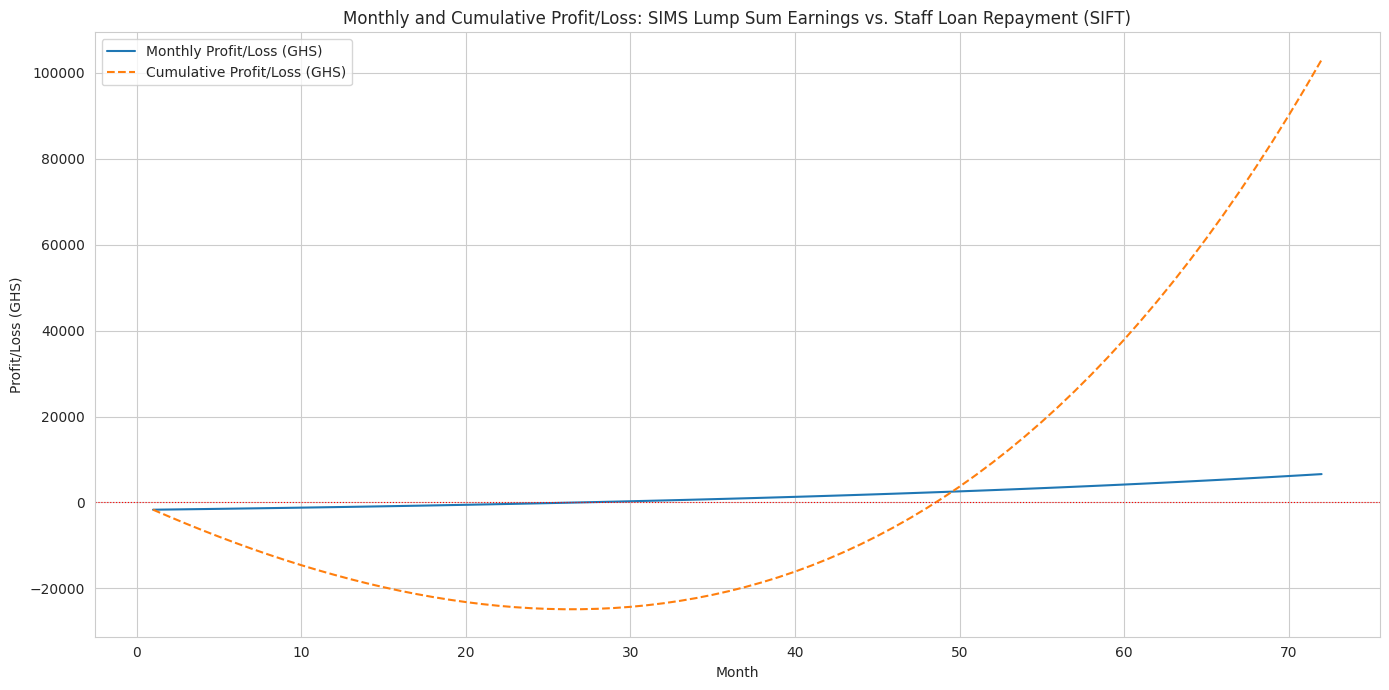

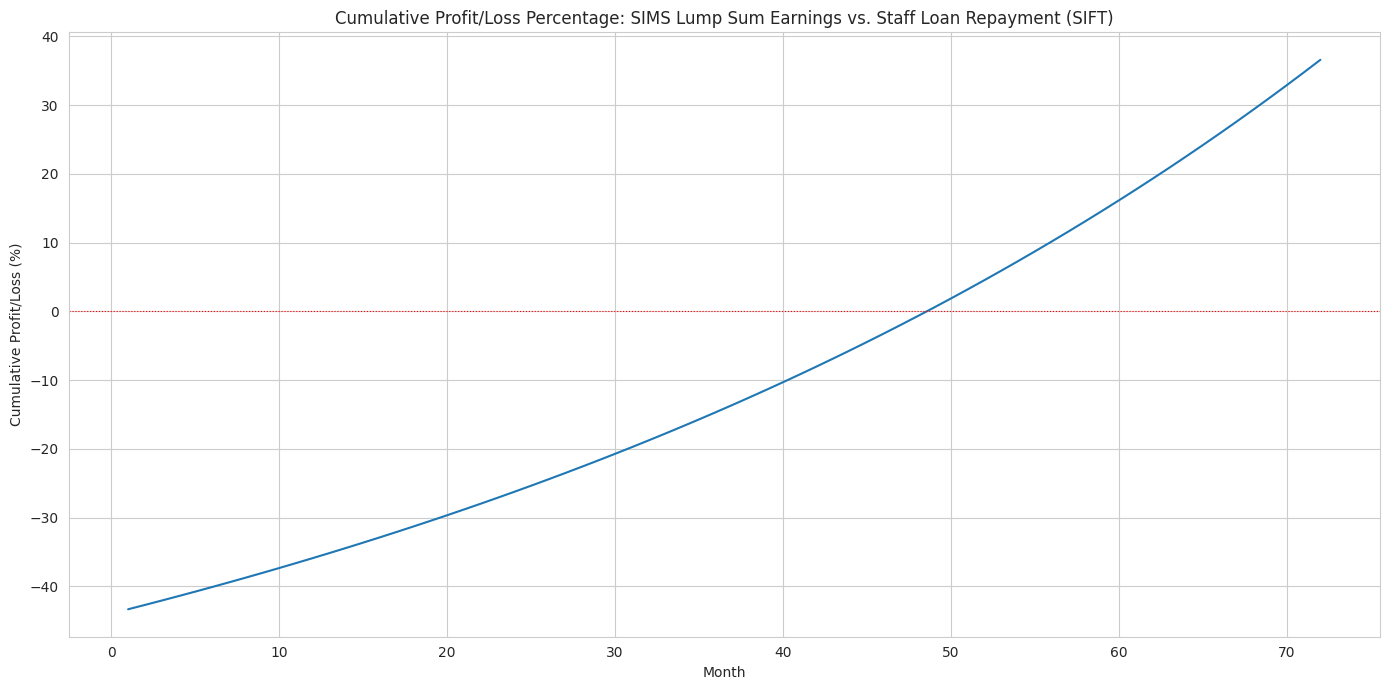

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")

# --- 1. Define Loan Parameters ---
# The lump sum amount invested is assumed to be the 'new_lump_sum_initial' read from B1 of the 'stanbic_sims' sheet
# which was used for the SIMS lump sum projection.
loan_amount_invested = new_lump_sum_initial # From Google Sheet B1, e.g., 200,000 GHS
monthly_loan_repayment = 3910.04 # Fixed value provided by the user: 'Staff Loan Repayment 3,910.04'

# The projection period (projection_months) is also from the previous Google Sheet read (B5)

# --- 2. Prepare SIMS Lump Sum Earnings Data ---
# We'll use the 'projected_lump_sum_sift' DataFrame for comparison, as it represents the lump sum scenario for SIFT.
# Assuming 'projected_lump_sum_sift' is available from the execution of cell `dec6054d`.

if 'projected_lump_sum_sift' not in locals() or projected_lump_sum_sift.empty:
    print("Error: 'projected_lump_sum_sift' DataFrame not found or is empty. Cannot perform comparison.")
    # Create an empty DataFrame as a fallback to prevent further errors
    sims_lump_sum_earnings = pd.DataFrame({'Month': range(1, projection_months + 1), 'SIMS Monthly Earnings (GHS)': 0.0})
else:
    sims_lump_sum_earnings = projected_lump_sum_sift[['Month', 'Monthly Earnings (GHS)']].copy()
    sims_lump_sum_earnings.rename(columns={'Monthly Earnings (GHS)': 'SIMS Monthly Earnings (GHS)'}, inplace=True)

# Ensure the SIMS earnings data covers the entire projection_months period
# This handles cases where projected_lump_sum_sift might be shorter than projection_months (though it shouldn't normally)
if len(sims_lump_sum_earnings) < projection_months:
    missing_months = pd.DataFrame({
        'Month': range(len(sims_lump_sum_earnings) + 1, projection_months + 1),
        'SIMS Monthly Earnings (GHS)': 0.0 # Assume 0 earnings for missing months
    })
    sims_lump_sum_earnings = pd.concat([sims_lump_sum_earnings, missing_months], ignore_index=True)


# --- 3. Create Comparison DataFrame ---
comparison_df = pd.DataFrame({'Month': range(1, projection_months + 1)})

# Add Loan Repayment
comparison_df['Loan Monthly Repayment (GHS)'] = monthly_loan_repayment

# Merge with SIMS earnings
comparison_df = pd.merge(comparison_df, sims_lump_sum_earnings, on='Month', how='left')

# Calculate Monthly Profit/Loss
comparison_df['Monthly P/L (GHS)'] = comparison_df['SIMS Monthly Earnings (GHS)'] - comparison_df['Loan Monthly Repayment (GHS)']

# Calculate Cumulative Loan Repayment
comparison_df['Cumulative Loan Repayment (GHS)'] = comparison_df['Loan Monthly Repayment (GHS)'].cumsum()

# Calculate Cumulative SIMS Earnings
comparison_df['Cumulative SIMS Earnings (GHS)'] = comparison_df['SIMS Monthly Earnings (GHS)'].cumsum()

# Calculate Cumulative Profit/Loss
comparison_df['Cumulative P/L (GHS)'] = comparison_df['Cumulative SIMS Earnings (GHS)'] - comparison_df['Cumulative Loan Repayment (GHS)']

# Calculate Monthly P/L (%)
comparison_df['Monthly P/L (%)'] = comparison_df.apply(
    lambda row: (row['Monthly P/L (GHS)'] / row['Loan Monthly Repayment (GHS)']) * 100
    if row['Loan Monthly Repayment (GHS)'] != 0 else np.nan, # Avoid division by zero
    axis=1
)

# Calculate Cumulative P/L (%)
comparison_df['Cumulative P/L (%)'] = comparison_df.apply(
    lambda row: (row['Cumulative P/L (GHS)'] / row['Cumulative Loan Repayment (GHS)']) * 100
    if row['Cumulative Loan Repayment (GHS)'] != 0 else np.nan, # Avoid division by zero
    axis=1
)

# --- 4. Display Comparison Table ---
print("\n--- Loan Repayment vs. SIMS Lump Sum Earnings Comparison (SIFT) ---")
print("First 5 months:")
display(comparison_df.head())
print("Last 5 months:")
display(comparison_df.tail())

# --- 5. Summary Metrics for the period ---
total_loan_repaid_period = comparison_df['Cumulative Loan Repayment (GHS)'].iloc[-1]
total_sims_earnings_period = comparison_df['Cumulative SIMS Earnings (GHS)'].iloc[-1]
total_profit_loss_period = comparison_df['Cumulative P/L (GHS)'].iloc[-1]
total_profit_loss_percent_period = comparison_df['Cumulative P/L (%)'].iloc[-1]

print(f"\nSummary for the {projection_months} months projection period:")
print(f"  Total Projected Loan Repayment: {total_loan_repaid_period:,.2f} GHS")
print(f"  Total Projected SIMS Earnings: {total_sims_earnings_period:,.2f} GHS")
print(f"  Total Projected Profit/Loss: {total_profit_loss_period:,.2f} GHS")
print(f"  Total Projected Profit/Loss (%): {total_profit_loss_percent_period:,.2f}%")

# --- 6. Plotting the comparison ---
plt.figure(figsize=(14, 7))
sns.lineplot(x='Month', y='Monthly P/L (GHS)', data=comparison_df, label='Monthly Profit/Loss (GHS)')
sns.lineplot(x='Month', y='Cumulative P/L (GHS)', data=comparison_df, label='Cumulative Profit/Loss (GHS)', linestyle='--')
plt.title('Monthly and Cumulative Profit/Loss: SIMS Lump Sum Earnings vs. Staff Loan Repayment (SIFT)')
plt.xlabel('Month')
plt.ylabel('Profit/Loss (GHS)')
plt.axhline(0, color='red', linestyle=':', linewidth=0.8) # Horizontal line at 0 for reference
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 7))
sns.lineplot(x='Month', y='Cumulative P/L (%)', data=comparison_df)
plt.title('Cumulative Profit/Loss Percentage: SIMS Lump Sum Earnings vs. Staff Loan Repayment (SIFT)')
plt.xlabel('Month')
plt.ylabel('Cumulative Profit/Loss (%)')
plt.axhline(0, color='red', linestyle=':', linewidth=0.8) # Horizontal line at 0 for reference
plt.grid(True)
plt.tight_layout()
plt.show()

In [37]:
import gspread
from google.colab import auth
from google.auth import default # Import default credentials function
import pandas as pd # Ensure pandas is imported

# Re-authenticate with Google (interactive user authentication)
auth.authenticate_user()

# Get default credentials in the google-auth format
creds, project = default()

# Authenticate gspread with the obtained credentials
gc = gspread.authorize(creds)

# Define the target spreadsheet and worksheet names
target_gsheet_url = 'https://docs.google.com/spreadsheets/d/1g62l5-q_uX2uX5MvC2p1Z6w_S0-3D7p7C9jY-9R-m0/edit?usp=sharing' # Assuming this is the URL for stanbic_sims_v_fidelity_loan
target_spreadsheet_name = 'stanbic_sims_v_fidelity_loan' # Name as specified by user
target_worksheet_name = 'Staff_Loan_Comparison'

try:
    # Open the target spreadsheet by URL
    spreadsheet = gc.open_by_url(target_gsheet_url)
    print(f"Successfully opened spreadsheet: {target_spreadsheet_name}")
except gspread.exceptions.SpreadsheetNotFound:
    # If not found by URL, try to open by name. If still not found, create it.
    print(f"Spreadsheet '{target_spreadsheet_name}' not found by URL. Attempting to open by name...")
    try:
        spreadsheet = gc.open(target_spreadsheet_name)
        print(f"Successfully opened spreadsheet by name: {target_spreadsheet_name}")
    except gspread.exceptions.SpreadsheetNotFound:
        print(f"Spreadsheet '{target_spreadsheet_name}' not found. Creating a new one...")
        spreadsheet = gc.create(target_spreadsheet_name)
        # Share with user if needed, or make it publicly editable
        spreadsheet.share(None, perm_type='anyone', role='writer')
        print(f"Created new spreadsheet: {target_spreadsheet_name} and shared publicly. URL: {spreadsheet.url}")

# Check if the target worksheet exists, create if not, or clear if it does
try:
    worksheet = spreadsheet.worksheet(target_worksheet_name)
    # Clear existing content if it exists
    worksheet.clear()
    print(f"Cleared existing worksheet: '{target_worksheet_name}'.")
except gspread.exceptions.WorksheetNotFound:
    worksheet = spreadsheet.add_worksheet(title=target_worksheet_name, rows="100", cols="20")
    print(f"Created new worksheet: '{target_worksheet_name}'.")

# Prepare the comparison_df data for writing
if 'comparison_df' in locals() and not comparison_df.empty:
    # Convert DataFrame to a list of lists (including header)
    data_to_write = [comparison_df.columns.tolist()] + comparison_df.values.tolist()

    # Update the worksheet with the data
    worksheet.update(values=data_to_write, range_name='A1')
    print(f"Comparison data written to worksheet '{target_worksheet_name}' starting at A1.")

    print("\n--- Instructions for Plotting in Google Sheets ---")
    print(f"1. Go to your Google Sheet: {spreadsheet.url}")
    print(f"2. Navigate to the '{target_worksheet_name}' tab.")
    print("3. Select the data range you wish to plot (e.g., A1:I61 for all data).")
    print("4. Go to 'Insert' > 'Chart'.")
    print("5. In the Chart editor, choose your desired chart type (e.g., 'Line chart' for cumulative values, 'Column chart' for monthly values).")
    print("6. Customize series, axes, and titles as needed. For example, for the cumulative profit/loss, you might plot 'Cumulative P/L (GHS)' against 'Month'.")
    print("--------------------------------------------------")
else:
    print("Error: 'comparison_df' not found or is empty. Cannot write comparison data to Google Sheet.")


Spreadsheet 'stanbic_sims_v_fidelity_loan' not found by URL. Attempting to open by name...
Successfully opened spreadsheet by name: stanbic_sims_v_fidelity_loan
Cleared existing worksheet: 'Staff_Loan_Comparison'.
Comparison data written to worksheet 'Staff_Loan_Comparison' starting at A1.

--- Instructions for Plotting in Google Sheets ---
1. Go to your Google Sheet: https://docs.google.com/spreadsheets/d/1TFE2NC9Iy_FtieIYVJTtJhKSVtnBsWzgl-Cm06WDw_k
2. Navigate to the 'Staff_Loan_Comparison' tab.
3. Select the data range you wish to plot (e.g., A1:I61 for all data).
4. Go to 'Insert' > 'Chart'.
5. In the Chart editor, choose your desired chart type (e.g., 'Line chart' for cumulative values, 'Column chart' for monthly values).
6. Customize series, axes, and titles as needed. For example, for the cumulative profit/loss, you might plot 'Cumulative P/L (GHS)' against 'Month'.
--------------------------------------------------


In [38]:
import gspread
from google.colab import auth
from google.auth import default # Import default credentials function
import pandas as pd # Ensure pandas is imported

# Re-authenticate with Google (interactive user authentication)
auth.authenticate_user()

# Get default credentials in the google-auth format
creds, project = default()

# Authenticate gspread with the obtained credentials
gc = gspread.authorize(creds)

# Define the target spreadsheet and worksheet names from the user's request
target_gsheet_url = 'https://docs.google.com/spreadsheets/d/1p5h13GBfHh3tpWQJ2w2RwUOA5p0g5OX1-EBNNT5yew0/edit?gid=84265370#gid=84265370'
target_worksheet_name = 'stanbic_sims_v_fidelity_loan'
start_cell = 'A4'

try:
    # Open the target spreadsheet by URL
    spreadsheet = gc.open_by_url(target_gsheet_url)
    print(f"Successfully opened spreadsheet: {spreadsheet.title}")
except gspread.exceptions.SpreadsheetNotFound:
    print(f"Error: Spreadsheet not found at URL: {target_gsheet_url}")
    print("Please ensure the URL is correct and you have access.")
    spreadsheet = None

if spreadsheet:
    try:
        # Open the target worksheet
        worksheet = spreadsheet.worksheet(target_worksheet_name)
        print(f"Successfully opened worksheet: '{target_worksheet_name}'.")
    except gspread.exceptions.WorksheetNotFound:
        print(f"Error: Worksheet '{target_worksheet_name}' not found in the spreadsheet.")
        print(f"Attempting to create worksheet '{target_worksheet_name}'...")
        try:
            worksheet = spreadsheet.add_worksheet(title=target_worksheet_name, rows="200", cols="20")
            print(f"Created new worksheet: '{target_worksheet_name}'.")
        except Exception as e:
            print(f"Failed to create worksheet: {e}")
            worksheet = None

if worksheet:
    # Prepare the comparison_df data for writing
    if 'comparison_df' in locals() and not comparison_df.empty:
        # Convert DataFrame to a list of lists (including header)
        # We need to write a descriptive header first, then the DataFrame header, then the data.
        # This ensures the output is readable even with a non-A1 start.

        output_data = [
            ['Staff Loan vs. SIMS Investment Comparison Data'], # Main title
            comparison_df.columns.tolist() # DataFrame column headers
        ] + comparison_df.values.tolist()

        # Update the worksheet with the data
        worksheet.update(values=output_data, range_name=start_cell)
        print(f"Comparison data written to worksheet '{target_worksheet_name}' starting at {start_cell}.")

        print("\n--- Instructions for Plotting in Google Sheets ---")
        print(f"1. Go to your Google Sheet: {spreadsheet.url}")
        print(f"2. Navigate to the '{target_worksheet_name}' tab.")
        print(f"3. Select the data range (e.g., from {start_cell} downwards, including headers).")
        print("4. Go to 'Insert' > 'Chart'.")
        print("5. In the Chart editor, choose your desired chart type (e.g., 'Line chart' for cumulative values, 'Column chart' for monthly values).")
        print("6. Customize series, axes, and titles as needed.")
        print("--------------------------------------------------")
    else:
        print("Error: 'comparison_df' not found or is empty. Cannot write comparison data to Google Sheet.")
else:
    print("Operation failed: Could not access or create the target worksheet.")


Successfully opened spreadsheet: Baobab SSOT Master
Successfully opened worksheet: 'stanbic_sims_v_fidelity_loan'.
Comparison data written to worksheet 'stanbic_sims_v_fidelity_loan' starting at A4.

--- Instructions for Plotting in Google Sheets ---
1. Go to your Google Sheet: https://docs.google.com/spreadsheets/d/1p5h13GBfHh3tpWQJ2w2RwUOA5p0g5OX1-EBNNT5yew0
2. Navigate to the 'stanbic_sims_v_fidelity_loan' tab.
3. Select the data range (e.g., from A4 downwards, including headers).
4. Go to 'Insert' > 'Chart'.
5. In the Chart editor, choose your desired chart type (e.g., 'Line chart' for cumulative values, 'Column chart' for monthly values).
6. Customize series, axes, and titles as needed.
--------------------------------------------------
